# Part 2:

Limitation(s) of sklearn’s non-negative matrix factorization library.

1. Load the movie ratings data (as in the HW3-recommender-system) and use matrix factorization technique(s) and predict the missing ratings from the test data. Measure the RMSE. You should use sklearn library.
2. Discuss the results and why sklearn's non-negative matrix facorization library did not work well compared to simple baseline or similarity-based methods we’ve done in Module 3. Can you suggest a way(s) to fix it?

In [3]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

In [7]:
users_df = pd.read_csv('data/users.csv')
movies_df = pd.read_csv('data/movies.csv')
train_df = pd.read_csv('data/train.csv')   # columns: uID, mID, rating
test_df = pd.read_csv('data/test.csv')     # columns: uID, mID, rating

# Build ID->index maps
uid2idx = dict(zip(users_df.uID.values, range(len(users_df))))
mid2idx = dict(zip(movies_df.mID.values, range(len(movies_df))))
n_users, n_items = len(users_df), len(movies_df)

# Sparse rating matrix from train
u_idx = train_df.uID.map(uid2idx).values
m_idx = train_df.mID.map(mid2idx).values
ratings = train_df.rating.astype(float).values
R = csr_matrix((ratings, (u_idx, m_idx)), shape=(n_users, n_items), dtype=np.float64)

# Helpers
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmse_on_test_from_matrix(Rhat: np.ndarray, test_df: pd.DataFrame) -> float:
    # Extract predictions at test coordinates
    ui = test_df.uID.map(uid2idx).values
    mi = test_df.mID.map(mid2idx).values
    y_true = test_df.rating.astype(float).values
    y_pred = Rhat[ui, mi]
    # Clip to rating scale
    y_pred = np.clip(y_pred, 1.0, 5.0)
    return rmse(y_true, y_pred)

# Baselines: global mean, user mean, item mean
global_mean = train_df.rating.mean()

user_mean = train_df.groupby('uID')['rating'].mean()
item_mean = train_df.groupby('mID')['rating'].mean()

def predict_user_mean(test_df):
    preds = test_df.uID.map(user_mean).fillna(global_mean).values
    return preds

def predict_item_mean(test_df):
    preds = test_df.mID.map(item_mean).fillna(global_mean).values
    return preds

def rmse_baseline(preds, test_df):
    return rmse(test_df.rating.values.astype(float), np.clip(preds, 1.0, 5.0))

rmse_global = rmse_baseline(np.full(len(test_df), global_mean), test_df)
rmse_user = rmse_baseline(predict_user_mean(test_df), test_df)
rmse_item = rmse_baseline(predict_item_mean(test_df), test_df)

print(f"Baseline RMSEs — global:{rmse_global:.4f}  user:{rmse_user:.4f}  item:{rmse_item:.4f}")

Baseline RMSEs — global:1.1162  user:1.0353  item:0.9798


/Users/drivera53/Development/python_projects/python3-12Env/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(
/Users/drivera53/Development/python_projects/python3-12Env/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(
/Users/drivera53/Development/python_projects/python3-12Env/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(
/Users/drivera53/Development/python_projects/python3-12Env/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


,rank,rmse
0,5,2.608640
1,10,2.566803
2,20,2.537119
3,50,2.551216
4,100,2.594866
5,150,2.631210


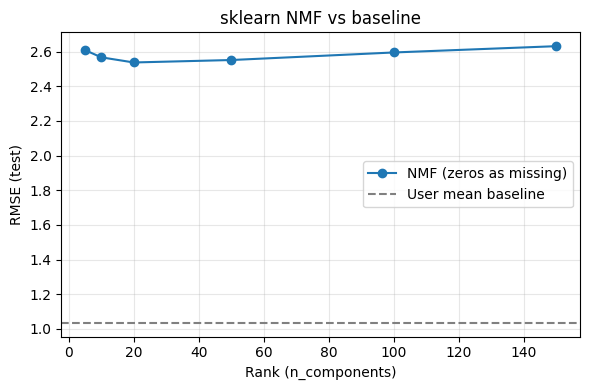

In [9]:
# sklearn NMF on sparse rating matrix (zeros treated as real 0s)
ranks = [5, 10, 20, 50, 100, 150]
nmf_results = []

for k in ranks:
    nmf = NMF(
        n_components=k,
        init='nndsvda',
        solver='cd',              # coordinate descent
        beta_loss='frobenius',    # squared loss
        max_iter=300,
        random_state=42,
        alpha_W=0.0,
        alpha_H=0.0,
        l1_ratio=0.0
    )
    W = nmf.fit_transform(R)       # accepts CSR
    H = nmf.components_
    Rhat = W @ H                   # dense reconstruction
    Rhat = np.clip(Rhat, 1.0, 5.0)
    score = rmse_on_test_from_matrix(Rhat, test_df)
    nmf_results.append({'rank': k, 'rmse': score})

nmf_df = pd.DataFrame(nmf_results)
display(nmf_df)

plt.figure(figsize=(6,4))
plt.plot(nmf_df['rank'], nmf_df['rmse'], marker='o', label='NMF (zeros as missing)')
plt.axhline(rmse_user, color='gray', ls='--', label='User mean baseline')
plt.xlabel('Rank (n_components)')
plt.ylabel('RMSE (test)')
plt.title('sklearn NMF vs baseline')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

/Users/drivera53/Development/python_projects/python3-12Env/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(
/Users/drivera53/Development/python_projects/python3-12Env/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(
/Users/drivera53/Development/python_projects/python3-12Env/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(
/Users/drivera53/Development/python_projects/python3-12Env/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


,rank,rmse
0,5,2.608640
1,10,2.566803
2,20,2.537119
3,50,2.551216
4,100,2.594866
5,150,2.631210


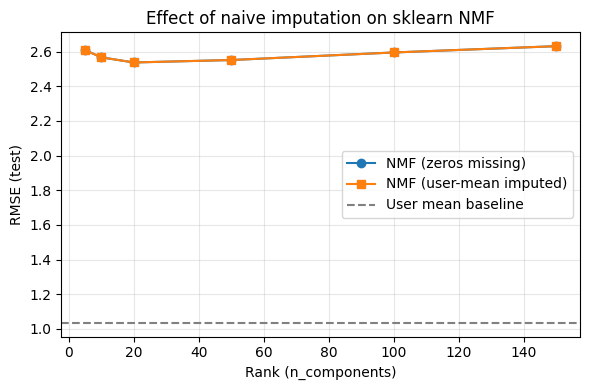

In [10]:
# NMF after simple user-mean imputation of missing entries
# Note: Still optimizes all entries equally; shown here to illustrate effect of imputation.
R_dense = R.toarray()
# Compute user means ignoring zeros
counts = (R_dense > 0).sum(axis=1)
means = np.divide(R_dense.sum(axis=1), counts, out=np.full_like(counts, global_mean, dtype=float), where=counts>0)
R_impute = R_dense.copy()
mask_zero = (R_impute == 0)
# R_impute[mask_zero] = means[:, None][mask_zero]

imputed_results = []
for k in ranks:
    nmf_imp = NMF(
        n_components=k,
        init='nndsvda',
        solver='cd',
        beta_loss='frobenius',
        max_iter=300,
        random_state=42
    )
    W = nmf_imp.fit_transform(R_impute)
    H = nmf_imp.components_
    Rhat = W @ H
    Rhat = np.clip(Rhat, 1.0, 5.0)
    score = rmse_on_test_from_matrix(Rhat, test_df)
    imputed_results.append({'rank': k, 'rmse': score})

imp_df = pd.DataFrame(imputed_results)
display(imp_df)

plt.figure(figsize=(6,4))
plt.plot(nmf_df['rank'], nmf_df['rmse'], marker='o', label='NMF (zeros missing)')
plt.plot(imp_df['rank'], imp_df['rmse'], marker='s', label='NMF (user-mean imputed)')
plt.axhline(rmse_user, color='gray', ls='--', label='User mean baseline')
plt.xlabel('Rank (n_components)')
plt.ylabel('RMSE (test)')
plt.title('Effect of naive imputation on sklearn NMF')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()